# Assignment 4
### Oleg Sanitskii   101466133


In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Data Preparation

We use the **CIFAR-10 dataset**, which contains **60,000 images across 10 classes**.

The original dataset is divided into:
- **50,000 training images**
- **10,000 test images**

For this project, the training portion is further split into:
- **40,000 training samples**
- **10,000 validation samples**

### 🔧 Steps performed:
- Normalize pixel values from **0–255** to **0–1**
- Split data into:
  - **Training set**
  - **Validation set**
  - **Test set**

This ensures proper evaluation and helps detect overfitting.

---

In [23]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

# Split validation
x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train = x_train[:-10000]
y_train = y_train[:-10000]

### Dataset Overview

---
Before training, we inspect the dataset to understand its structure.

We verify:
- Number of samples
- Image shape
- Number of classes
---

In [24]:
print("Training samples:", x_train.shape)
print("Test samples:", x_test.shape)
print("Image shape:", x_train[0].shape)

print("Number of classes:", len(np.unique(y_train)))

Training samples: (40000, 32, 32, 3)
Test samples: (10000, 32, 32, 3)
Image shape: (32, 32, 3)
Number of classes: 10


In [50]:
print("Unique label values:", np.unique(y_train))

Unique label values: [0 1 2 3 4 5 6 7 8 9]


In [51]:
for i in range(10):
    print(f"Label {i} -> {class_names[i]}")

Label 0 -> airplane
Label 1 -> automobile
Label 2 -> bird
Label 3 -> cat
Label 4 -> deer
Label 5 -> dog
Label 6 -> frog
Label 7 -> horse
Label 8 -> ship
Label 9 -> truck


In [49]:
import pandas as pd

df_preview = pd.DataFrame({
    "Image Index": list(range(10)),
    "Label": [class_names[int(y_train[i][0])] for i in range(10)]
})

df_preview

,Image Index,Label
0,0,frog
1,1,truck
2,2,truck
3,3,deer
4,4,automobile
5,5,automobile
6,6,bird
7,7,horse
8,8,ship
9,9,cat


### 🖼️ Sample Images from CIFAR-10

Below are examples of images from the dataset.
This helps us visually understand the data the model is learning from.

---

/tmp/ipykernel_39487/4210215054.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


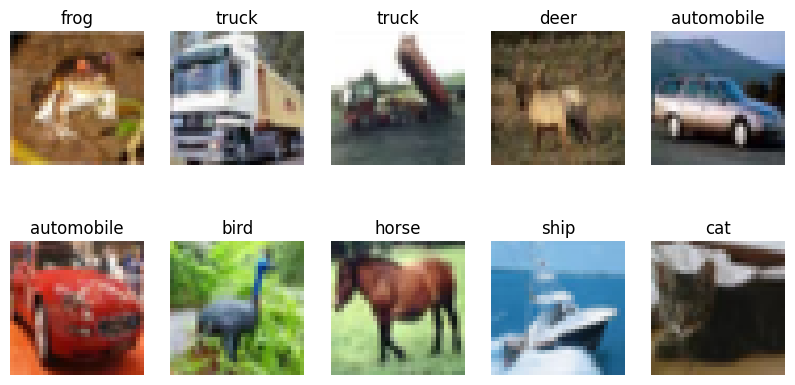

In [25]:
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")
plt.show()

###  Class Distribution
---
We check how data is distributed across classes to ensure balance.
The dataset is evenly distributed across all classes, which helps prevent bias during training.


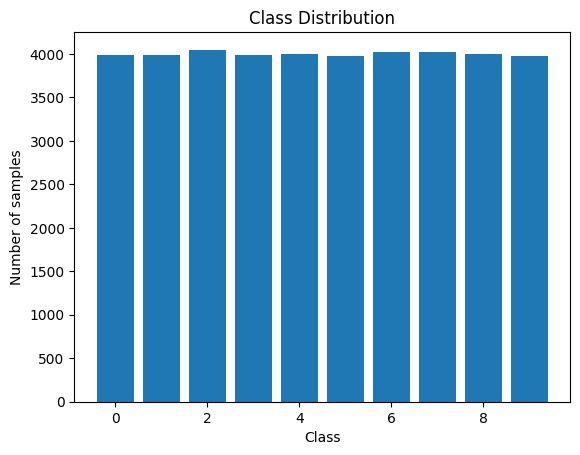

In [26]:
unique, counts = np.unique(y_train, return_counts=True)

plt.bar(unique, counts)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.show()

## Model 1 — Overfitting Example

This model is intentionally designed with **too many parameters**.

### 🧠 Key idea:
- Large Dense layers
- No regularization

👉 This often leads to **overfitting**, where the model memorizes training data instead of generalizing.

---

In [27]:
model_overfit = keras.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_overfit.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model_overfit.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_val, y_val)
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3185 - loss: 1.8868 - val_accuracy: 0.3704 - val_loss: 1.7397
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3920 - loss: 1.6978 - val_accuracy: 0.3771 - val_loss: 1.7195
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4166 - loss: 1.6190 - val_accuracy: 0.4132 - val_loss: 1.6230
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4366 - loss: 1.5656 - val_accuracy: 0.4428 - val_loss: 1.5724
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4505 - loss: 1.5284 - val_accuracy: 0.4565 - val_loss: 1.5380
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4636 - loss: 1.4954 - val_accuracy: 0.4596 - val_loss: 1.5266
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4668 - loss: 1.4746 - val_accuracy: 0.4224 - val_loss: 1.6045
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4787 - loss: 1.4511 - 

### Graph 1 — Training vs Validation Loss

This graph shows how the model behaves during training.

### 🔍 Observation:
- Training loss continuously decreases
- Validation loss stops improving and fluctuates

👉 This is a clear sign of **overfitting**

---

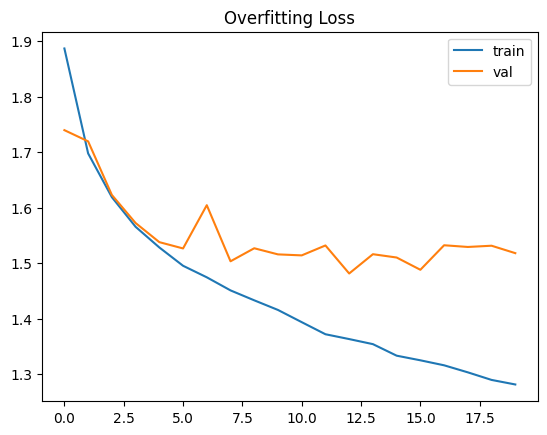

In [28]:
plt.plot(history1.history['loss'], label='train')
plt.plot(history1.history['val_loss'], label='val')
plt.legend()
plt.title("Overfitting Loss")
plt.show()

## Model 2 — Dropout Regularization

To reduce overfitting, we introduce **Dropout layers**.

### ⚙️ What Dropout does:
- Randomly disables neurons during training
- Forces the network to learn more robust features

👉 This helps reduce overfitting but may also reduce accuracy if too strong.

---

In [29]:
model_dropout = keras.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model_dropout.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_val, y_val)
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1484 - loss: 2.2218 - val_accuracy: 0.1907 - val_loss: 2.0809
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1604 - loss: 2.1576 - val_accuracy: 0.1980 - val_loss: 2.0716
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1633 - loss: 2.1454 - val_accuracy: 0.2162 - val_loss: 2.0600
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1718 - loss: 2.1348 - val_accuracy: 0.2091 - val_loss: 2.0769
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1776 - loss: 2.1175 - val_accuracy: 0.2134 - val_loss: 2.0401
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1794 - loss: 2.1151 - val_accuracy: 0.2447 - val_loss: 2.0339
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1827 - loss: 2.1088 - val_accuracy: 0.2139 - val_loss: 2.0585
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1858 - loss: 2.1050 - 

### Graph 2 — Dropout Model Accuracy

This graph shows accuracy for the dropout model.

### 🔍 Observation:
- Accuracy is lower than Model 1
- Model is less confident

👉 This suggests possible **underfitting due to strong regularization**

---

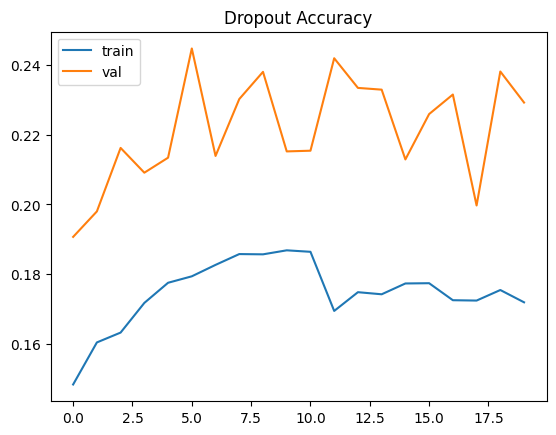

In [30]:
plt.plot(history2.history['accuracy'], label='train')
plt.plot(history2.history['val_accuracy'], label='val')
plt.legend()
plt.title("Dropout Accuracy")
plt.show()

## Model 3 — Data Augmentation + CNN

This model uses **Convolutional Neural Networks (CNNs)** and **Data Augmentation**.

### ⚙️ Improvements:
- CNN layers capture spatial features
- Data augmentation increases dataset diversity

👉 This helps the model generalize better.

---

In [31]:
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True
)

model_aug = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model_aug.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(x_val, y_val)
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.4151 - loss: 1.6140 - val_accuracy: 0.5345 - val_loss: 1.3218
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.5326 - loss: 1.3159 - val_accuracy: 0.5586 - val_loss: 1.2496
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.5716 - loss: 1.2121 - val_accuracy: 0.5922 - val_loss: 1.1680
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.6038 - loss: 1.1265 - val_accuracy: 0.6302 - val_loss: 1.0684
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.6220 - loss: 1.0718 - val_accuracy: 0.6450 - val_loss: 1.0174
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.6385 - loss: 1.0335 - val_accuracy: 0.6616 - val_loss: 0.9855
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.6525 - loss: 0.9998 - val_accuracy: 0.6541 - val_loss: 1.0132
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.6577 -

### 🔄 Data Augmentation

We apply transformations such as:
- Rotation
- Horizontal flipping

👉 This creates new variations of images and improves generalization.

---

In [32]:
history3 = model_aug.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(x_val, y_val)
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.7325 - loss: 0.7714 - val_accuracy: 0.7132 - val_loss: 0.8570
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.7316 - loss: 0.7682 - val_accuracy: 0.7030 - val_loss: 0.8887
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.7372 - loss: 0.7513 - val_accuracy: 0.7178 - val_loss: 0.8437
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.7395 - loss: 0.7488 - val_accuracy: 0.7288 - val_loss: 0.8165
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.7433 - loss: 0.7342 - val_accuracy: 0.7176 - val_loss: 0.8541
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.7470 - loss: 0.7278 - val_accuracy: 0.7171 - val_loss: 0.8459
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.7462 - loss: 0.7292 - val_accuracy: 0.7076 - val_loss: 0.8743
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.7495 -

### Graph 3 — Validation Loss Comparison

This graph compares validation loss across all models.

### 🔍 Observation:
- Model 1: overfitting
- Model 2: high loss (underfitting)
- Model 3: lowest loss

👉 Data augmentation significantly improves performance.

---

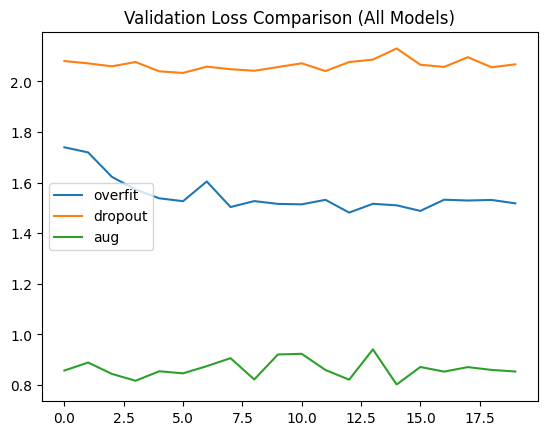

In [33]:
plt.plot(history1.history['val_loss'], label='overfit')
plt.plot(history2.history['val_loss'], label='dropout')
plt.plot(history3.history['val_loss'], label='aug')
plt.legend()
plt.title("Validation Loss Comparison (All Models)")
plt.show()

### Graph 4 — Validation Accuracy Comparison

This graph compares accuracy across models.

### 🔍 Observation:
- Model 3 achieves the highest accuracy (~73%)
- Model 1 performs moderately
- Model 2 performs the worst

👉 Data augmentation + CNN provides the best results.

---

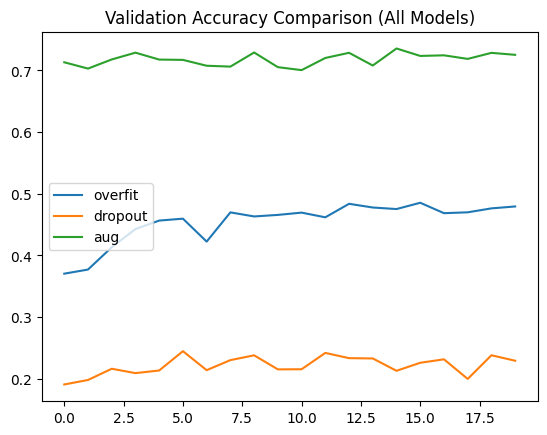

In [34]:
plt.plot(history1.history['val_accuracy'], label='overfit')
plt.plot(history2.history['val_accuracy'], label='dropout')
plt.plot(history3.history['val_accuracy'], label='aug')
plt.legend()
plt.title("Validation Accuracy Comparison (All Models)")
plt.show()

## Test Evaluation

The dataset was divided into three parts:

- **Training set** → used to train the model  
- **Validation set** → used to detect overfitting  
- **Test set** → used for final evaluation  

### 📌 Results:
- Model 1: moderate performance (overfitting)
- Model 2: low performance (underfitting)
- Model 3: best performance (good generalization)

👉 The test results confirm that Model 3 is the most effective.

---

In [35]:
test_loss, test_acc = model_aug.evaluate(x_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7252 - loss: 0.8468
Test Loss: 0.8467976450920105
Test Accuracy: 0.7251999974250793


In [36]:
print("Overfit model:", model_overfit.evaluate(x_test, y_test))
print("Dropout model:", model_dropout.evaluate(x_test, y_test))
print("Aug model:", model_aug.evaluate(x_test, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4825 - loss: 1.5035
Overfit model: [1.5035111904144287, 0.48249998688697815]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2276 - loss: 2.0674
Dropout model: [2.0673561096191406, 0.22759999334812164]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7252 - loss: 0.8468
Aug model: [0.8467976450920105, 0.7251999974250793]


## Prediction Examples

Below are sample predictions made by the best-performing model (**Model 3**).

This helps us visually inspect whether the model classifies unseen test images correctly.

Green titles indicate correct predictions, while red titles indicate incorrect predictions.

---

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


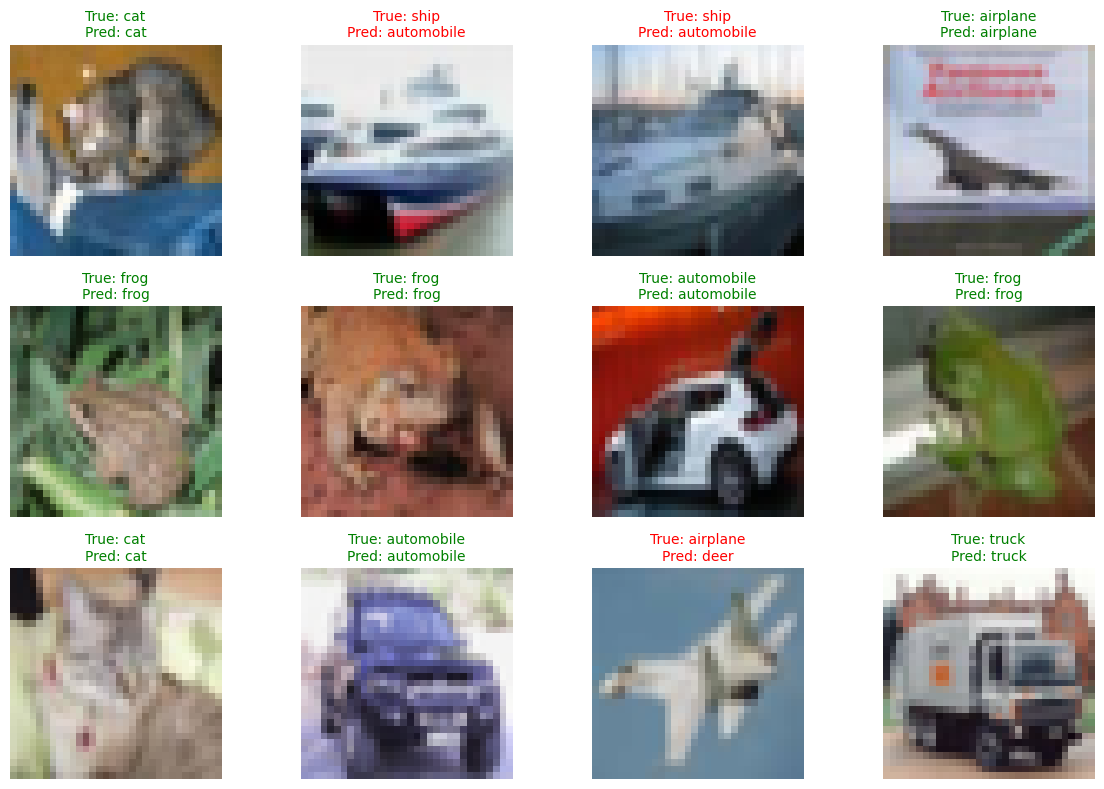

In [39]:
pred_probs = model_aug.predict(x_test)
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i])

    true_label = int(y_test[i][0])
    pred_label = pred_labels[i]

    color = "green" if true_label == pred_label else "red"

    plt.title(
        f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
        color=color,
        fontsize=10
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

### Why Some Classes Are Confused

Some classes are confused more often because CIFAR-10 images are very small (**32×32 pixels**).

For example:
- **ships** may be confused with **automobiles**

This happens because the model learns visual patterns such as shape, color, and texture rather than human-level semantic meaning.  
Low image resolution makes these differences harder to detect.

## 🧩 Confusion Matrix

This matrix shows how the model predicts each class.

- Rows (left) → **True labels**
- Columns (bottom) → **Predicted labels**
- Diagonal → ✅ Correct predictions
- Off-diagonal → ❌ Errors (misclassifications)

Darker cells indicate higher values.

---

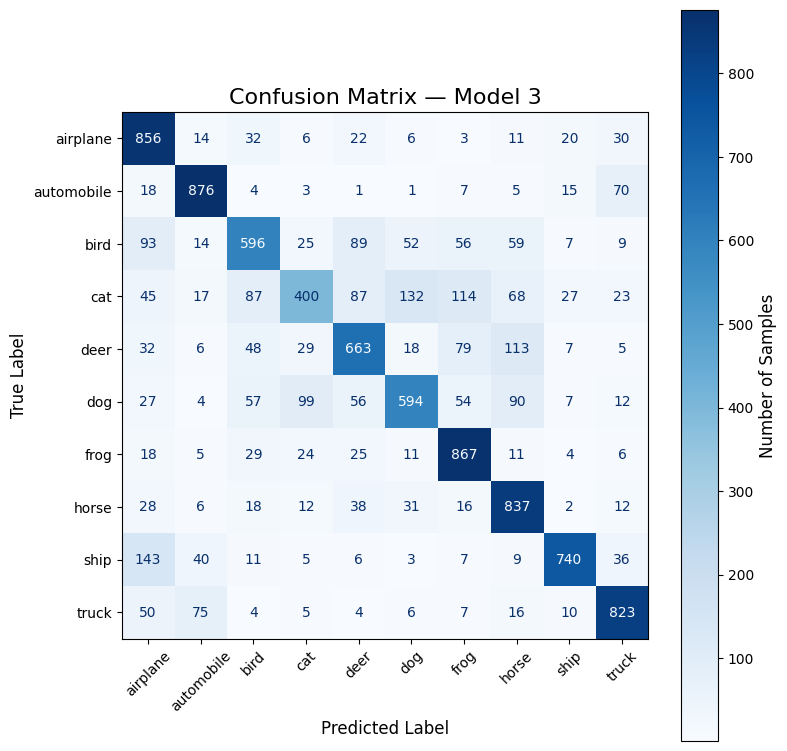

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test.flatten(), pred_labels)

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=True
)
disp.im_.colorbar.set_label("Number of Samples", fontsize=12)

plt.title("Confusion Matrix — Model 3", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.show()

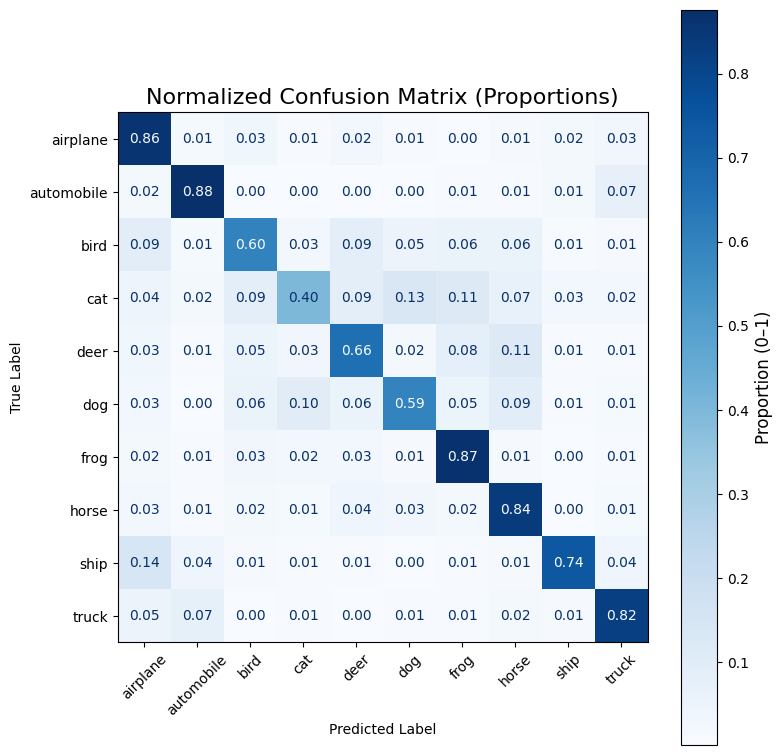

In [46]:
cm_norm = confusion_matrix(y_test.flatten(), pred_labels, normalize='true')

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=True,
    values_format=".2f"
)
disp.im_.colorbar.set_label("Proportion (0–1)", fontsize=12)

plt.title("Normalized Confusion Matrix (Proportions)", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

### 📌 How to Read the Normalized Confusion Matrix

Each row represents a **true class**, and values in that row sum to 1 (100%).

For example:
- In the "airplane" row:
  - 0.86 → 86% of airplanes are correctly classified
  - 0.01 → 1% are misclassified as automobiles
  - 0.03 → 3% are misclassified as birds

👉 Therefore, we interpret the matrix **row by row**, not column by column.

Columns answer a different question (where predictions come from), but rows show how each true class is classified.

### 📌 Confusion Matrix Analysis

The confusion matrix shows how the model performs across different classes.

### ✅ Strong performance:
The model performs well on clearly distinguishable classes such as:
- frog
- truck
- automobile
- horse

These classes have high values along the diagonal, indicating correct predictions.

---

### ⚠️ Common misclassifications:

Some classes are frequently confused:

- **Ship ↔ Airplane**
  - Ships are sometimes predicted as airplanes
  - This may be due to similar backgrounds (sky or water)

- **Cat ↔ Dog**
  - These classes are visually similar, especially in low-resolution images

- **Deer ↔ Horse**
  - Similar shapes and poses lead to confusion

---

### 🧠 Interpretation:

These errors occur because the model learns **visual patterns** (shapes, textures, colors) rather than human-level understanding.

Since CIFAR-10 images are small (**32×32 pixels**), fine details are often lost, making some classes harder to distinguish.

---

### 🚀 Conclusion:

The confusion matrix confirms that while the model achieves good overall accuracy, it still struggles with visually similar classes.

This highlights the importance of:
- Better architectures
- Higher resolution data
- More advanced training techniques

## Discussion and Conclusion

---

### Overparameterization
The first model is **overparameterized**, meaning it has too many weights.  
This leads to **overfitting**, where the model performs well on training data but poorly on validation data.

---

### Convolutional Neural Networks (CNNs)
CNNs were used in Model 3 to capture **spatial patterns** in images such as edges and shapes.  
This significantly improves performance compared to fully connected layers.

---

### Epoch Analysis
The first model begins to **overfit after around 8–10 epochs**.  
In contrast, the augmented model continues improving, showing better generalization.

---

### Regularization Effects
Dropout helps reduce overfitting but can sometimes cause **underfitting** if applied too aggressively.

---

### Final Conclusion
- Overfitting occurs in complex models without regularization  
- Dropout can help but must be balanced  
- Data augmentation + CNN provides the **best overall performance**

---